In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/heart_statlog_cleveland_hungary_final (2).csv")

print(df.head())
print(df.info())
print(df.describe())
print(df['target'].value_counts())

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            0             172                0      0.0         1       0  
1            0             156                0      1.0         2       1  
2            1              98                0      0.0         1       0  
3            0             108                1      1.5         2       1  
4            0             122                0      0.0         1       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 en

In [5]:
df = df.dropna()

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
y_pred_rf = rf_model.predict(X_test)

Random Forest Accuracy: 0.9495798319327731
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94       107
           1       0.95      0.96      0.95       131

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238



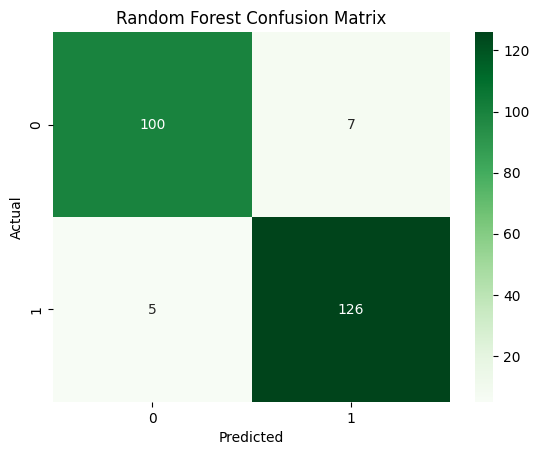

In [11]:
#Import Required Libraries
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, cmap="Greens", fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [12]:
pip install xgboost

In [13]:

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("/content/heart_statlog_cleveland_hungary_final (2).csv")
X = df.drop("target", axis=1)
y = df["target"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])


param_grid = {
    "xgb__n_estimators": [100, 200],
    "xgb__max_depth": [3, 5, 7],
    "xgb__learning_rate": [0.01, 0.1, 0.2],
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
print(" Best Params:", grid.best_params_)
print(" Classification Report:\n", classification_report(y_test, y_pred))
print(" Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


joblib.dump(grid.best_estimator_, "xgboost_heart_model.pkl")
print(" Model saved as 'xgboost_heart_model.pkl'")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
 Best Params: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 7, 'xgb__n_estimators': 100}
 Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.91      0.92       107
           1       0.93      0.95      0.94       131

    accuracy                           0.93       238
   macro avg       0.93      0.93      0.93       238
weighted avg       0.93      0.93      0.93       238

 Confusion Matrix:
 [[ 97  10]
 [  6 125]]
 Model saved as 'xgboost_heart_model.pkl'


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:23:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [14]:
pip install tensorflow

In [16]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib


df = pd.read_csv("/content/heart_statlog_cleveland_hungary_final (2).csv")
X = df.drop("target", axis=1)
y = df["target"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler_nn.pkl")


model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))  # Binary output


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)


y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

model.save("heart_nn_model.h5")
print("✅ Neural network model saved as 'heart_nn_model.h5'")


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5974 - loss: 0.6763 - val_accuracy: 0.7749 - val_loss: 0.5246
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8237 - loss: 0.4731 - val_accuracy: 0.7853 - val_loss: 0.4733
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8246 - loss: 0.4238 - val_accuracy: 0.7906 - val_loss: 0.4612
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8398 - loss: 0.3759 - val_accuracy: 0.7853 - val_loss: 0.4555
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8371 - loss: 0.3895 - val_accuracy: 0.7853 - val_loss: 0.4517
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8418 - loss: 0.3662 - val_accuracy: 0.7958 - val_loss: 0.4478
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8298 - loss: 0.3930 - val_accuracy: 0.7906 - val_loss: 0.4432
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8421 - loss: 0.3823 - val_accuracy: 0.7958 - 

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       107
           1       0.88      0.92      0.90       131

    accuracy                           0.89       238
   macro avg       0.89      0.88      0.88       238
weighted avg       0.89      0.89      0.89       238

Confusion Matrix:
 [[ 91  16]
 [ 11 120]]
✅ Neural network model saved as 'heart_nn_model.h5'


In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [18]:
from sklearn.metrics import accuracy_score
import joblib
import tensorflow as tf

xgb_model = joblib.load("xgboost_heart_model.pkl")
nn_model = tf.keras.models.load_model("heart_nn_model.h5")
scaler_nn = joblib.load("scaler_nn.pkl")

def ensemble_predict_batch(X):

    rf_preds = rf_model.predict(X)


    xgb_preds = xgb_model.predict(X)


    X_scaled_nn = scaler_nn.transform(X)
    nn_probs = nn_model.predict(X_scaled_nn)
    nn_preds = (nn_probs > 0.5).astype(int).flatten()


    final_preds = []
    for rf, xgb, nn in zip(rf_preds, xgb_preds, nn_preds):
        votes = [rf, xgb, nn]
        final = max(set(votes), key=votes.count)
        final_preds.append(final)

    return np.array(final_preds)

In [19]:
ensemble_preds = ensemble_predict_batch(X_test)
accuracy = accuracy_score(y_test, ensemble_preds)
print("🎯 Ensemble Model Accuracy:", round(accuracy * 100, 2), "%")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


🎯 Ensemble Model Accuracy: 89.5 %


In [20]:
pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.2/54.2 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.1/323.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.9 MB/s eta 0:00:00


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import gradio as gr
import traceback

df = pd.read_csv("/content/heart_statlog_cleveland_hungary_final (2).csv")
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled, y_train)


xgb_model = XGBClassifier(eval_metric="logloss")
xgb_model.fit(X_train_scaled, y_train)


nn_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
nn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
nn_model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, verbose=0)


def safe_predict(*args):
    try:
        input_data = [[float(x) for x in args]]

        if len(input_data[0]) != 11:
            return f"❌ Error: Expected 11 features, got {len(input_data[0])}"

        input_scaled = scaler.transform(input_data)

        rf_pred = rf_model.predict(input_scaled)[0]
        xgb_pred = xgb_model.predict(input_scaled)[0]
        nn_pred_prob = nn_model.predict(input_scaled)[0][0]
        nn_pred = int(nn_pred_prob > 0.5)

        preds = [rf_pred, xgb_pred, nn_pred]
        final_pred = int(sum(preds) >= 2)

        return "❤️ Has Heart Disease" if final_pred else "✅ No Heart Disease"

    except Exception as e:
        return f"❌ Internal Error: {str(e)}\n{traceback.format_exc()}"

inputs = [
    gr.Number(label="Age"),
    gr.Number(label="Sex (1=Male, 0=Female)"),
    gr.Number(label="Chest Pain Type (0-3)"),
    gr.Number(label="Resting Blood Pressure"),
    gr.Number(label="Cholesterol"),
    gr.Number(label="Fasting Blood Sugar (1 if >120 mg/dl)"),
    gr.Number(label="Resting ECG (0-2)"),
    gr.Number(label="Max Heart Rate"),
    gr.Number(label="Exercise Angina (1=Yes, 0=No)"),
    gr.Number(label="Oldpeak (ST depression)"),
    gr.Number(label="ST Slope (0-2)")
]


gr.Interface(fn=safe_predict, inputs=inputs, outputs="text", title="❤️ Heart Disease Predictor").launch()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://24e5dea85832935011.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# streamlit_app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load the trained model
with open("heart_disease_model.pkl", "rb") as file:
    model = pickle.load(file)

st.title("Heart Disease Prediction System")

st.markdown("Enter the patient data below:")

# Input fields
age = st.number_input("Age", min_value=1, max_value=120, value=30)
sex = st.selectbox("Sex", options=[0, 1], format_func=lambda x: "Male" if x == 1 else "Female")
cp = st.selectbox("Chest Pain Type (cp)", options=[0, 1, 2, 3])
trestbps = st.number_input("Resting Blood Pressure (trestbps)", min_value=80, max_value=200, value=120)
chol = st.number_input("Serum Cholesterol in mg/dl (chol)", min_value=100, max_value=600, value=200)
fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl (fbs)", options=[0, 1])
restecg = st.selectbox("Resting Electrocardiographic Results (restecg)", options=[0, 1, 2])
thalach = st.number_input("Maximum Heart Rate Achieved (thalach)", min_value=60, max_value=250, value=150)
exang = st.selectbox("Exercise Induced Angina (exang)", options=[0, 1])
oldpeak = st.number_input("ST depression induced by exercise (oldpeak)", min_value=0.0, max_value=10.0, step=0.1)
slope = st.selectbox("Slope of the peak exercise ST segment (slope)", options=[0, 1, 2])
ca = st.selectbox("Number of major vessels (ca)", options=[0, 1, 2, 3, 4])
thal = st.selectbox("Thalassemia (thal)", options=[0, 1, 2, 3])

# Prediction
if st.button("Predict"):
    input_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg,
                            thalach, exang, oldpeak, slope, ca, thal]])

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.error("The model predicts that the person has heart disease.")
    else:
        st.success("The model predicts that the person does not have heart disease.")


ModuleNotFoundError: No module named 'streamlit'